##BehaviorGuard — Final Credit Card Fraud Detection Analysis

his is the consolidated "final analysis" file for the project.

##01. IMPORTS AND CONFIGURATION

In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency, rankdata
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    balanced_accuracy_score
)

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = Path("../data/processed/transactions_behavioral.csv")
RESULT_DIR = Path("../results/final_analysis")
FIGURE_DIR = RESULT_DIR / "figures"
MODEL_DIR = RESULT_DIR / "models"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("Environment setup complete. All necessary libraries imported and directories created.")


Environment setup complete. All necessary libraries imported and directories created.


02.  Load Data and Analysis dataset

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found:\n{DATA_PATH.resolve()}\n\n"
        "Make sure the processed dataset is located at "
        "../data/processed/transactions_behavioral.csv"
    )

df = pd.read_csv(DATA_PATH)

print("\n[1] DATASET")
print("-" * 80)
print("Shape:", df.shape)
print("Columns:", len(df.columns))

if "Class" not in df.columns:
    raise ValueError("Target column 'Class' was not found.")

print("\nTarget distribution:")
print(df["Class"].value_counts())

print("\nTarget percentage:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))



[1] DATASET
--------------------------------------------------------------------------------
Shape: (283726, 39)
Columns: 39

Target distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Target percentage:
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


In [4]:
print("\n[2] DATA QUALITY")
print("-" * 80)

missing = df.isna().sum()
missing = missing[missing > 0]

print("Missing values:")
print(missing if not missing.empty else "None")

print("\nDuplicate rows:", int(df.duplicated().sum()))

print("\nTarget values:", sorted(df["Class"].dropna().unique().tolist()))

if df["Class"].isna().any():
    raise ValueError("Target contains missing values.")

# Remove exact duplicate rows only if any are found.
# The project dataset previously contained zero duplicates, so this should
# normally leave the dataset unchanged.
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)



[2] DATA QUALITY
--------------------------------------------------------------------------------
Missing values:
None

Duplicate rows: 0

Target values: [0, 1]


##Feature Engineering for Final Analysis 

In [9]:


# Temporal analysis feature.
# This is derived from Time and is used for analysis, not as raw Time input.
if "Time" in df.columns:
    df["Transaction_Hour"] = (df["Time"] / 3600.0) % 24
    df["Transaction_Hour_Int"] = df["Transaction_Hour"].astype(int)

# Identifiers / technical columns that should not be learned as predictors.
EXCLUDE_COLUMNS = {
    "Class",
    "level_0",
    "index",
    "Transaction_Time",
    "Transaction_Hour",
    "Transaction_Hour_Int",
}

feature_columns = [
    c for c in df.columns
    if c not in EXCLUDE_COLUMNS
]

In [10]:
# Behavioral features already engineered earlier in the project.
BEHAVIORAL_FEATURES = [
    "Amount_Log",
    "Amount_Category",
    "Transactions_Last_1H",
    "Transactions_Last_24H",
    "Amount_ZScore",
]

BEHAVIORAL_FEATURES = [
    c for c in BEHAVIORAL_FEATURES if c in df.columns
]

In [11]:
# Numeric/categorical split.
numeric_features = [
    c for c in feature_columns
    if pd.api.types.is_numeric_dtype(df[c])
]

categorical_features = [
    c for c in feature_columns
    if not pd.api.types.is_numeric_dtype(df[c])
]

In [12]:
print("Total model features:", len(feature_columns))
print("Numerical features:", len(numeric_features))
print("Categorical features:", categorical_features)
print("Behavioral features:", BEHAVIORAL_FEATURES)


Total model features: 37
Numerical features: 35
Categorical features: ['Time_Period', 'Amount_Category']
Behavioral features: ['Amount_Log', 'Amount_Category', 'Transactions_Last_1H', 'Transactions_Last_24H', 'Amount_ZScore']


##04. Class counts

In [16]:

normal_count = int((df["Class"] == 0).sum())
fraud_count = int((df["Class"] == 1).sum())
fraud_rate = fraud_count / len(df)

print("\n[4] CLASS BALANCE : \n")

print(f"Normal transactions : {normal_count:,}")
print(f"Fraud transactions  : {fraud_count:,}")
print(f"Fraud rate          : {fraud_rate:.4%}")




[4] CLASS BALANCE : 

Normal transactions : 283,253
Fraud transactions  : 473
Fraud rate          : 0.1667%


##05. Leakage-Safe-Train / Validation /Teat split

First split off 20% test data.From the remaining 80%, create a 20% validation split. This produces approximately: 64% train, 16% validation, 20% test.

In [18]:


X = df[feature_columns].copy()
y = df["Class"].astype(int).copy()

# First split off 20% test data.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)


In [20]:
# From the remaining 80%, create a 20% validation split.
# This produces approximately:
#   64% train, 16% validation, 20% test.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)


In [21]:
print("Train:", X_train.shape, "Fraud:", int(y_train.sum()))
print("Valid:", X_valid.shape, "Fraud:", int(y_valid.sum()))
print("Test :", X_test.shape, "Fraud:", int(y_test.sum()))


Train: (181584, 37) Fraud: 302
Valid: (45396, 37) Fraud: 76
Test : (56746, 37) Fraud: 95


## 06. Preprocessing Pipeline

Numeric features: median imputation, standardization
Categorical features:most-frequent imputation, one-hot encoding. The preprocessing is fitted only on training data through Pipeline / ColumnTransformer, preventing preprocessing leakage.

In [22]:

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [23]:

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)


##07. Model Definations

 Class imbalance is severe, so class_weight="balanced" is used for the sklearn models. For XGBoost, scale_pos_weight is calculated from training data only.


In [27]:
scale_pos_weight = (
    (len(y_train) - int(y_train.sum()))
    / max(int(y_train.sum()), 1)
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ),
}

# XGBoost is optional only in the sense that the script gives a clear error
# if the package is not installed. The project already used XGBoost.
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

except ImportError as exc:
    raise ImportError(
        "XGBoost is required for the final project analysis. "
        "Install it with: pip install xgboost"
    ) from exc



##08. Train models and collect validation / test scores

In [29]:
fitted_models = {}
model_results = []
validation_probabilities = {}
test_probabilities = {}

for model_name, estimator in models.items():

    print(f"\nTraining {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    pipeline.fit(X_train, y_train)

    fitted_models[model_name] = pipeline

    # Validation probabilities are used only for threshold selection.
    valid_prob = pipeline.predict_proba(X_valid)[:, 1]

    # Test probabilities are reserved for final evaluation.
    test_prob = pipeline.predict_proba(X_test)[:, 1]

    validation_probabilities[model_name] = valid_prob
    test_probabilities[model_name] = test_prob

    # Default 0.50 threshold metrics.
    test_pred = (test_prob >= 0.50).astype(int)

    precision = precision_score(
        y_test, test_pred, zero_division=0
    )
    recall = recall_score(
        y_test, test_pred, zero_division=0
    )
    f1 = f1_score(
        y_test, test_pred, zero_division=0
    )
    pr_auc = average_precision_score(
        y_test, test_prob
    )
    roc_auc = roc_auc_score(
        y_test, test_prob
    )
    balanced_acc = balanced_accuracy_score(
        y_test, test_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test, test_pred
    ).ravel()

    model_results.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Balanced_Accuracy": balanced_acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })



Training Logistic Regression...

Training Random Forest...

Training XGBoost...


In [33]:
# Save fitted model for each trained estimator.
safe_name = (
    model_name.lower()
    .replace(" ", "_")
)

joblib.dump(
    pipeline,
    MODEL_DIR / f"{safe_name}.joblib"
)

model_results_df = pd.DataFrame(model_results)

print("\nModel benchmark:")
print(
    model_results_df[
        [
            "Model",
            "Precision",
            "Recall",
            "F1",
            "PR_AUC",
            "ROC_AUC",
            "Balanced_Accuracy",
        ]
    ].round(4).to_string(index=False)
)



Model benchmark:
              Model  Precision  Recall     F1  PR_AUC  ROC_AUC  Balanced_Accuracy
Logistic Regression     0.0507  0.8737 0.0958  0.6896   0.9694             0.9231
      Random Forest     0.9459  0.7368 0.8284  0.8118   0.9489             0.8684
            XGBoost     0.9259  0.7895 0.8523  0.8105   0.9662             0.8947


## 09. Confusion Matrices

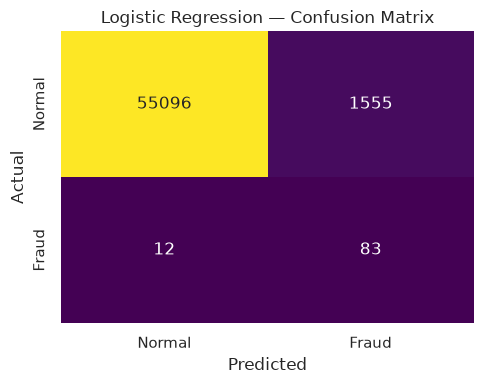

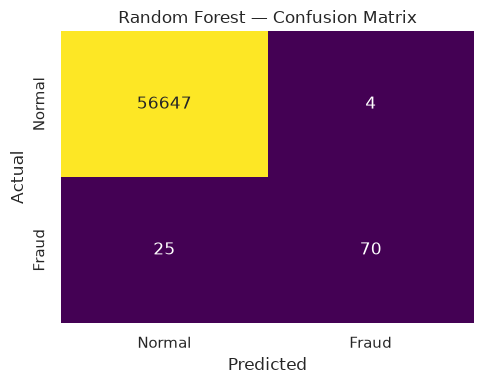

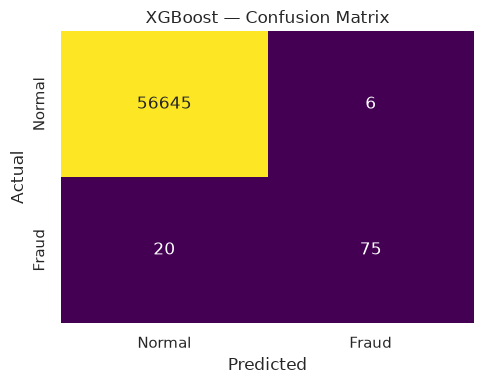

In [40]:
for model_name, test_prob in test_probabilities.items():

    test_pred = (test_prob >= 0.50).astype(int)
    cm = confusion_matrix(y_test, test_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=["Normal", "Fraud"],
        yticklabels=["Normal", "Fraud"],
        cmap="viridis"
    )

    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    plt.show()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()



##10. Precision Recall and ROC-CURVES

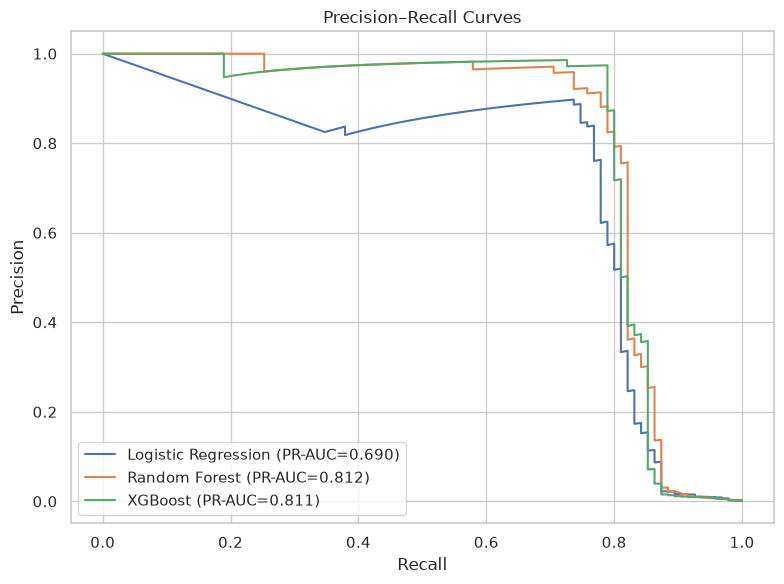

In [41]:
plt.figure(figsize=(8, 6))

for model_name, test_prob in test_probabilities.items():

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test,
        test_prob
    )

    pr_auc = average_precision_score(
        y_test,
        test_prob
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.tight_layout()

plt.show()

plt.savefig(
    FIGURE_DIR / "precision_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

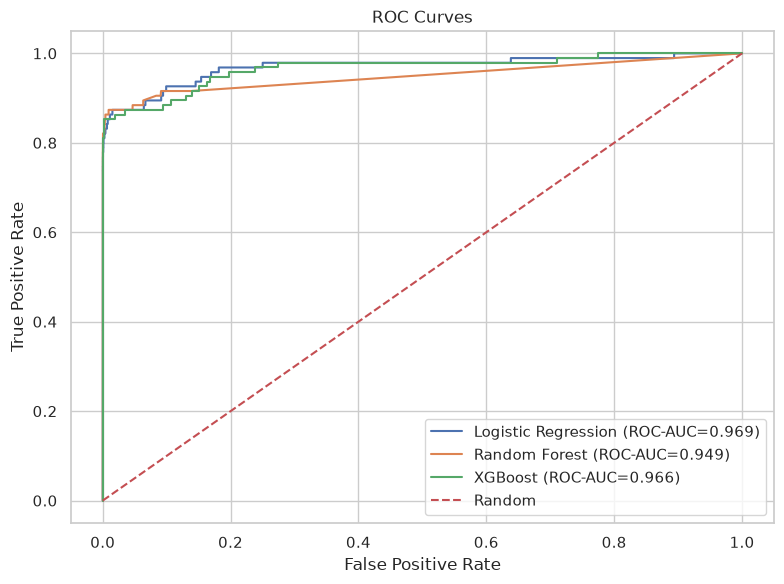

In [42]:
plt.figure(figsize=(8, 6))

for model_name, test_prob in test_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        test_prob
    )

    roc_auc = roc_auc_score(
        y_test,
        test_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (ROC-AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()

plt.show()

plt.savefig(
    FIGURE_DIR / "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()